In [1]:
import torch
import numpy as np
from torch import nn
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

In [2]:
preprocess = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))])

In [3]:
datapath = "datasets/train"

imagepath = ImageFolder(datapath, transform=preprocess)
train_loader = DataLoader(imagepath, batch_size=64, shuffle=True)

In [4]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 3) #6, 62, 62 #image size reduces as padding is not set
        self.conv2 = nn.Conv2d(6, 16, 3) #16, 60, 60 
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(16*60*60, 128) #latent_dim = 128

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.flatten(x)
        out = self.fc(x)
        return out

In [5]:
enc = Encoder()
for image, _ in train_loader:
    print(enc(image).shape)
    break

C:\Users\praveenchakra.bh\AppData\Local\Programs\Python\Python39\lib\site-packages\PIL\Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


torch.Size([64, 128])


In [6]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(128, 16*60*60)
        self.conv1 = nn.ConvTranspose2d(16, 6, 3)
        self.conv2 = nn.ConvTranspose2d(6, 1, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 16, 60, 60) #this is for conversion from 2d to 4d similar to above
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        return x

In [7]:
dec = Decoder()
for image, _ in train_loader:
    x = enc(image)
    print(x.shape)
    y = dec(x)
    print(y.shape)
    original = image[0].detach().cpu().squeeze(0)
    recon = y[0].detach().cpu().squeeze(0)
    break

torch.Size([64, 128])
torch.Size([64, 1, 64, 64])


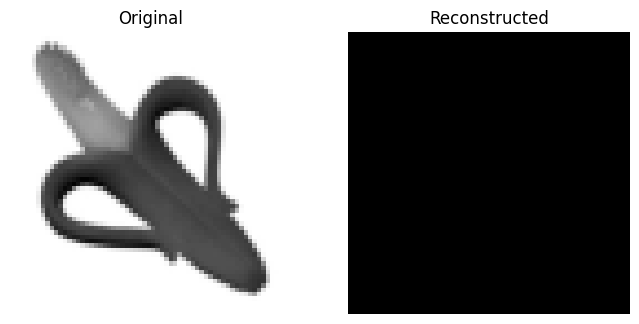

In [8]:
import matplotlib.pyplot as plt


# Plot side-by-side
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(original, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Reconstructed")
plt.imshow(recon, cmap='gray')
plt.axis('off')

plt.show()

In [9]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = Encoder()
        self.dec = Decoder()

    def forward(self, x):
        x = self.enc(x)
        out = self.dec(x)
        return out

In [10]:
model = AutoEncoder()

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
loss_fn = nn.MSELoss()

In [12]:
epochs = 300

for i in range(epochs):
    total_loss = 0
    model.train()
    for image, _ in train_loader:
        optimizer.zero_grad()
        image = image.view(-1, 1, 64, 64)
        output = model(image)
        loss = loss_fn(output, image)
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
    if i % 10 == 0:
        print(f"EPOCH: {i+1} and Total Loss: {total_loss}")

C:\Users\praveenchakra.bh\AppData\Local\Programs\Python\Python39\lib\site-packages\PIL\Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


EPOCH: 1 and Total Loss: 15.045846104621887
EPOCH: 11 and Total Loss: 1.0431812703609467
EPOCH: 21 and Total Loss: 0.8931284844875336
EPOCH: 31 and Total Loss: 0.7760526835918427
EPOCH: 41 and Total Loss: 0.7129012048244476
EPOCH: 51 and Total Loss: 0.6882592439651489
EPOCH: 61 and Total Loss: 0.6710058301687241
EPOCH: 71 and Total Loss: 0.6580787152051926
EPOCH: 81 and Total Loss: 0.6449500024318695
EPOCH: 91 and Total Loss: 0.6329209208488464
EPOCH: 101 and Total Loss: 0.6206822693347931
EPOCH: 111 and Total Loss: 0.6132287085056305
EPOCH: 121 and Total Loss: 0.6011379510164261
EPOCH: 131 and Total Loss: 0.594858855009079
EPOCH: 141 and Total Loss: 0.5835762917995453
EPOCH: 151 and Total Loss: 0.5682237595319748
EPOCH: 161 and Total Loss: 0.5572033524513245
EPOCH: 171 and Total Loss: 0.5434471368789673
EPOCH: 181 and Total Loss: 0.5395508110523224
EPOCH: 191 and Total Loss: 0.52958744764328
EPOCH: 201 and Total Loss: 0.5181014090776443
EPOCH: 211 and Total Loss: 0.5093814581632614
EP

In [13]:
from PIL import Image

img = Image.open("test/apple.jpg").convert("L")
img_tensor = preprocess(img)
img_tensor = img_tensor.unsqueeze(0)

model.eval()
with torch.no_grad():
    reconstructed = model(img_tensor)

original = img_tensor.squeeze().cpu()
recon = reconstructed.squeeze().cpu()

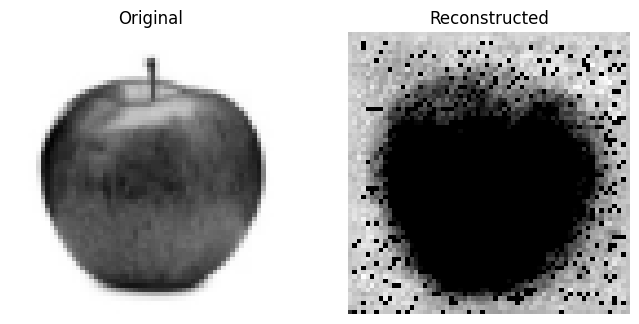

In [14]:
# Plot side-by-side
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(original, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Reconstructed")
plt.imshow(recon, cmap='gray')
plt.axis('off')

plt.show()

In [15]:
## Compression rate

image_size = 64*64 *1
compression_rate = (1 - 128 / image_size) * 100
print(f"Compression Rate is : {compression_rate}")

Compression Rate is : 96.875
